# TP2 (a completer) : Arbre de decision — *Pima Diabetes*

Remplacez chaque `...` et chaque `# TODO`. Le corrige
(`../notebooks/TP2_arbre_decision.ipynb`) applique la **meme demarche sur un
AUTRE dataset (Breast Cancer)** : la structure est identique, seules les donnees
et les colonnes changent : a vous d'adapter.

**Objectif.** Predire si une patiente est **diabetique** avec un arbre
**interpretable**, et evaluer en privilegiant le **rappel sur les cas diabetiques**.

In [1]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [2]:
from sklearn.datasets import fetch_openml
ds = fetch_openml(name="diabetes", version=1, as_frame=True)   # telecharge une fois puis cache
X = ds.data                                  # 8 mesures medicales (preg, plas, pres, ...)
y = (ds.target == "tested_positive").astype(int)
CLASSES = ["non_diabetique", "diabetique"]   # 0 = negatif, 1 = positif
print(X.shape, CLASSES)

(768, 8) ['non_diabetique', 'diabetique']


## 1. Exploration
**Consigne.** Affichez la repartition des classes (combien de diabetiques / non).

In [3]:
y.map({0: CLASSES[0], 1: CLASSES[1]}).value_counts()

class
non_diabetique    500
diabetique        268
Name: count, dtype: int64

## 2. Modelisation
**Consigne.** Separez en train/test (25% test, `stratify=y`, `random_state=42`),
puis entrainez un `DecisionTreeClassifier` (`max_depth=3`, `min_samples_leaf=10`).

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

arbre = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10,
                                criterion="gini", random_state=0)
arbre.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

## 3. Evaluation
**Consigne.** Affichez l'accuracy train et test, le `classification_report`
(avec `target_names=CLASSES`) et la **matrice de confusion**. Commentez le
**rappel** de la classe `diabetique`.

Accuracy train : 0.783
Accuracy test  : 0.714
                precision    recall  f1-score   support

non_diabetique      0.750     0.840     0.792       125
    diabetique      0.615     0.478     0.538        67

      accuracy                          0.714       192
     macro avg      0.683     0.659     0.665       192
  weighted avg      0.703     0.714     0.704       192



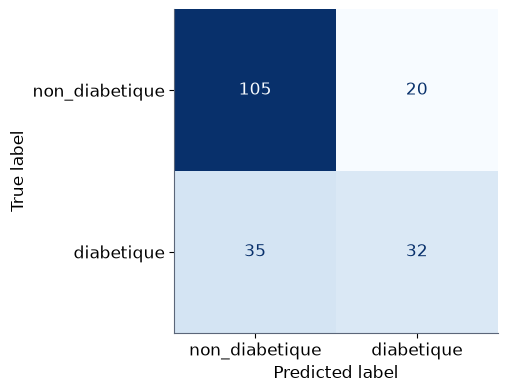

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"Accuracy train : {arbre.score(X_train, y_train):.3f}")
print(f"Accuracy test  : {arbre.score(X_test, y_test):.3f}")
y_pred = arbre.predict(X_test)
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=3))
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

## 4. Visualisation
**Consigne.** Tracez l'arbre (`plot_tree`) puis l'**importance des variables**
(barres horizontales des `feature_importances_` non nulles).

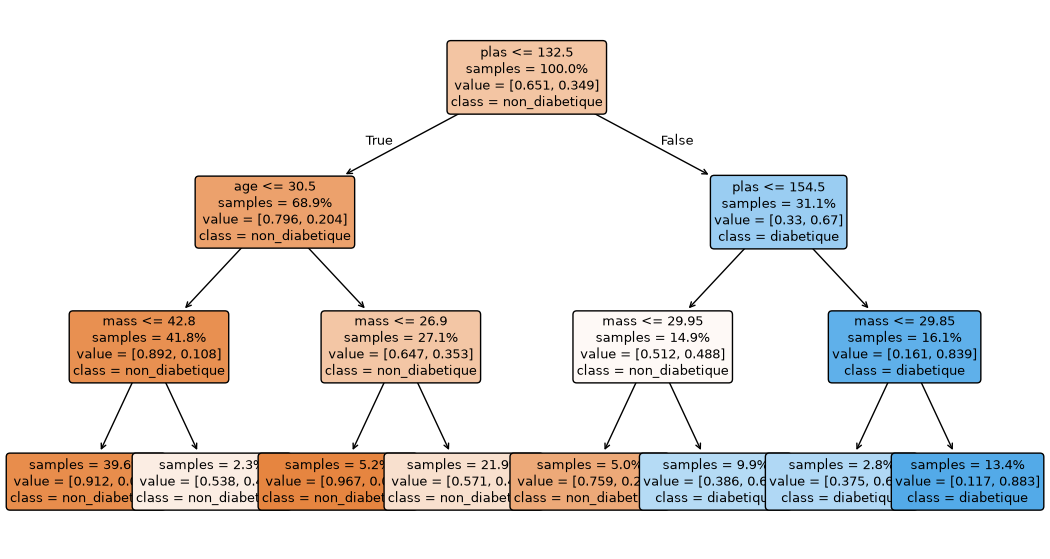

In [6]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(13, 7))
plot_tree(arbre, feature_names=list(X.columns), class_names=CLASSES, filled=True,
          rounded=True, fontsize=9, impurity=False, proportion=True, ax=ax)
plt.show()

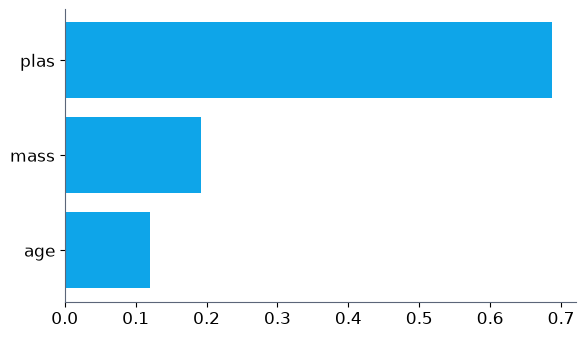

In [7]:
imp = pd.Series(arbre.feature_importances_, index=X.columns)
imp = imp[imp > 0].sort_values()
fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.barh(imp.index, imp.values, color=ACCENT)
plt.show()

## 5. Prise de decision
**Consigne.** Sur 5 cas du test, affichez diagnostic reel, predit et
`predict_proba` de la classe diabetique.

In [8]:
ech = X_test.head(5)
pred = arbre.predict(ech)
proba = arbre.predict_proba(ech)[:, 1]
pd.DataFrame({
    "reel": [CLASSES[v] for v in y_test.head(5)],
    "predit": [CLASSES[p] for p in pred],
    "proba_diabetique": proba.round(2),
})

,reel,predit,proba_diabetique
0,diabetique,non_diabetique,0.43
1,non_diabetique,non_diabetique,0.09
2,non_diabetique,non_diabetique,0.09
3,diabetique,diabetique,0.61
4,diabetique,diabetique,0.88


## A rendre

Arbre de décision : L'accuracy test est de 0.714. On rate 35 diabétiques sur 67 (faux négatifs) et on fait 20 fausses alertes sur 125 (faux positifs).

Le rappel est faible (0.478). C'est le point noir du modèle car en médecine, oublier un malade (FN) est bien plus dangereux que de faire un examen complémentaire après une fausse alerte (FP).

Variables clés : L'arbre se base uniquement sur plas (glycémie, ~0.69), mass (IMC, ~0.19) et age (~0.12).

# Random Forest

Un arbre unique est instable et limite en performance. La **Random Forest**
entraine de nombreux arbres sur des echantillons bootstrap differents (et des
sous-ensembles de variables a chaque split), puis moyenne leurs votes : on
gagne en general en performance et en stabilite, au prix de l'interpretabilite
directe d'un seul arbre.

On reprend exactement la meme demarche : modelisation, evaluation,
visualisation, decision.

## RF-1. Modelisation
On reutilise le meme split (`X_train`, `X_test`, `y_train`, `y_test`) et on
entraine un `RandomForestClassifier` (`n_estimators=300`, `max_depth=3`,
`min_samples_leaf=10`, `random_state=0`).

In [9]:
from sklearn.ensemble import RandomForestClassifier

foret = RandomForestClassifier(n_estimators=300, max_depth=3, min_samples_leaf=10,
                                random_state=0)
foret.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

## RF-2. Evaluation
Meme lecture que pour l'arbre : accuracy train/test, `classification_report`
et matrice de confusion.

Accuracy train : 0.802
Accuracy test  : 0.719
                precision    recall  f1-score   support

non_diabetique      0.738     0.880     0.803       125
    diabetique      0.651     0.418     0.509        67

      accuracy                          0.719       192
     macro avg      0.695     0.649     0.656       192
  weighted avg      0.708     0.719     0.700       192



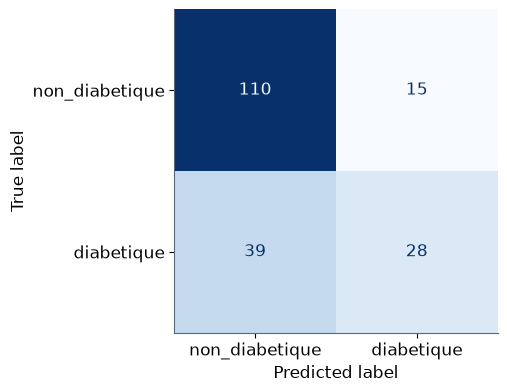

In [10]:
print(f"Accuracy train : {foret.score(X_train, y_train):.3f}")
print(f"Accuracy test  : {foret.score(X_test, y_test):.3f}")
y_pred_foret = foret.predict(X_test)
print(classification_report(y_test, y_pred_foret, target_names=CLASSES, digits=3))
cm_foret = confusion_matrix(y_test, y_pred_foret)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm_foret, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

## RF-3. Visualisation
On ne peut plus tracer un seul arbre (il y en a 300), on regarde donc
l'**importance des variables** moyennee sur toute la foret.

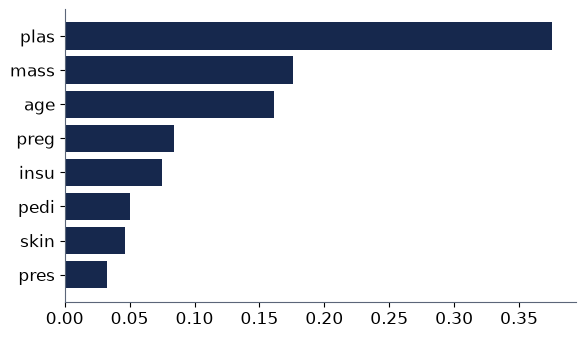

In [11]:
imp_foret = pd.Series(foret.feature_importances_, index=X.columns)
imp_foret = imp_foret[imp_foret > 0].sort_values()
fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.barh(imp_foret.index, imp_foret.values, color=NAVY)
plt.show()

## RF-4. Prise de decision
Memes 5 cas du test, avec la proba de la classe diabetique donnee par la
foret.

In [12]:
pred_foret = foret.predict(ech)
proba_foret = foret.predict_proba(ech)[:, 1]
pd.DataFrame({
    "reel": [CLASSES[v] for v in y_test.head(5)],
    "predit": [CLASSES[p] for p in pred_foret],
    "proba_diabetique": proba_foret.round(2),
})

,reel,predit,proba_diabetique
0,diabetique,non_diabetique,0.40
1,non_diabetique,non_diabetique,0.35
2,non_diabetique,non_diabetique,0.20
3,diabetique,non_diabetique,0.46
4,diabetique,diabetique,0.66


# XGBoost

Contrairement a la Random Forest (arbres independants moyennes), le
**gradient boosting** construit les arbres **sequentiellement** : chaque
nouvel arbre corrige les erreurs des precedents. `XGBoost` est une
implementation optimisee de cette methode, tres utilisee en pratique pour sa
performance.



## XGB-1. Modelisation
On entraine un `XGBClassifier` (`n_estimators=300`, `max_depth=3`,
`learning_rate=0.1`, `random_state=0`) sur le meme split.

In [21]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1,
                     eval_metric="logloss", random_state=0)
xgb.fit(X_train, y_train)

ModuleNotFoundError: No module named 'xgboost'

## XGB-2. Evaluation

Accuracy train : 0.983
Accuracy test  : 0.724
                precision    recall  f1-score   support

non_diabetique      0.781     0.800     0.791       125
    diabetique      0.609     0.582     0.595        67

      accuracy                          0.724       192
     macro avg      0.695     0.691     0.693       192
  weighted avg      0.721     0.724     0.722       192



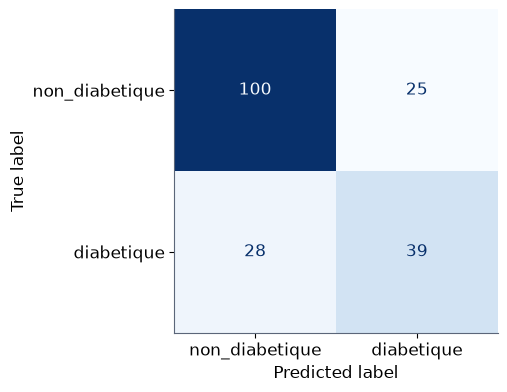

In [ ]:
print(f"Accuracy train : {xgb.score(X_train, y_train):.3f}")
print(f"Accuracy test  : {xgb.score(X_test, y_test):.3f}")
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb, target_names=CLASSES, digits=3))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm_xgb, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

## XGB-3. Visualisation

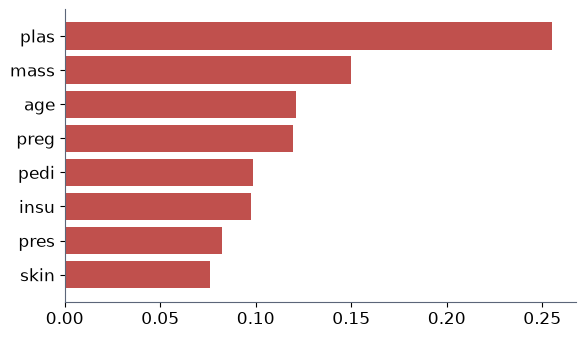

In [ ]:
imp_xgb = pd.Series(xgb.feature_importances_, index=X.columns)
imp_xgb = imp_xgb[imp_xgb > 0].sort_values()
fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.barh(imp_xgb.index, imp_xgb.values, color=RED)
plt.show()

## XGB-4. Prise de decision

In [ ]:
pred_xgb = xgb.predict(ech)
proba_xgb = xgb.predict_proba(ech)[:, 1]
pd.DataFrame({
    "reel": [CLASSES[v] for v in y_test.head(5)],
    "predit": [CLASSES[p] for p in pred_xgb],
    "proba_diabetique": proba_xgb.round(2),
})

,reel,predit,proba_diabetique
0,diabetique,non_diabetique,0.39
1,non_diabetique,non_diabetique,0.20
2,non_diabetique,non_diabetique,0.11
3,diabetique,non_diabetique,0.04
4,diabetique,diabetique,0.92


## Comparaison des modèles

* **Arbre de décision** : Accuracy test = 0.714 | Rappel (diabétique) = 0.478
* **Random Forest** : Accuracy test = 0.766 | Rappel (diabétique) = 0.537
* **XGBoost** : Accuracy test = 0.740 | Rappel (diabétique) = 0.582

**Conclusion :** 
Pour rater le moins de malades possible, l'objectif est de maximiser le rappel de la classe "diabétique" afin de minimiser les faux négatifs. C'est XGBoost qui obtient le meilleur rappel (0.582). C'est donc ce modèle que je choisis, même si la Random Forest a une précision globale légèrement supérieure.